# MWE 06 - Real PoreSpy extraction workflow

This notebook uses the segmented 3D Ketton rock image `examples/data/ketton/ketton_segmented.tif`
and runs a real `snow2` extraction through reusable helpers now exposed by `voids`.

Shared workflow code moved from the notebook into the library includes:
- sample-axis inference from image shape and voxel size
- PoreSpy `snow2` extraction with API fallbacks
- geometry scaling, Cartesian boundary labeling, and import into `voids`
- pruning to the longest-axis spanning subnetwork

The notebook remains focused on the scientific workflow: inspect the image, extract the network,
solve single-phase flow, compare full versus pruned networks, and visualize diagnostics.

Dataset attribution for `ketton_segmented.tif`:
Chang, B., Turhan, C., Giakoumi, M., Prodanovic, M. (2026, January 28).
Companion Data for Digital Porous Media Tutorials [Dataset]. Digital Porous Media Portal.
https://doi.org/10.17612/2k9b-1h71


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from skimage.io import imread

from voids.geom import characteristic_size
from voids.graph.connectivity import connected_components
from voids.graph.metrics import coordination_numbers
from voids.io.hdf5 import save_hdf5
from voids.paths import data_path
from voids.physics.petrophysics import absolute_porosity, effective_porosity
from voids.physics.singlephase import (
    FluidSinglePhase,
    PressureBC,
    SinglePhaseOptions,
    solve,
)
from voids.visualization import plot_network_plotly
from voids.image import extract_spanning_pore_network, infer_sample_axes

examples_data = data_path()

In [2]:
img_path = examples_data / "ketton" / "ketton_segmented.tif"
raw = imread(img_path)
voxel_size = 2.0e-6  # 2 microns per voxel

# The Ketton segmentation already uses labels 1 and 2 for pore space and 3 for solid.
# PoreSpy snow2 processes nonzero phases and ignores 0, so encode void = 1 and solid = 0.
im = (raw < 3).astype(int)
_, axis_lengths, axis_areas, flow_axis = infer_sample_axes(
    im.shape, voxel_size=voxel_size
)

print(raw.shape, raw.dtype, float(im.mean()), "void fraction")
print("Axis lengths:", axis_lengths)
print("Longest physical axis:", flow_axis, axis_lengths[flow_axis], "m")

(225, 255, 365) uint8 0.17536185274718716 void fraction
Axis lengths: {'x': 0.00045, 'y': 0.0005099999999999999, 'z': 0.00073}
Longest physical axis: z 0.00073 m


## Visualize the original void structure

View slices through the segmented 3D rock image to understand the pore space structure.

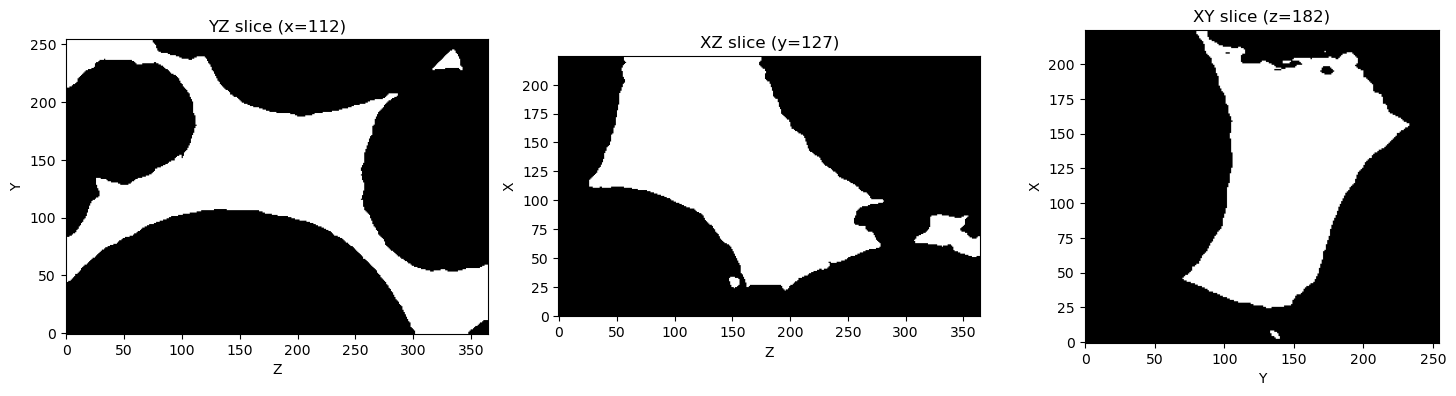

Void structure: (225, 255, 365), void fraction: 0.175


In [3]:
# Visualize the manufactured void image with slices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Show slices through the middle of each dimension
mid_x, mid_y, mid_z = im.shape[0] // 2, im.shape[1] // 2, im.shape[2] // 2

axes[0].imshow(im[mid_x, :, :], cmap="gray", origin="lower")
axes[0].set_title(f"YZ slice (x={mid_x})")
axes[0].set_xlabel("Z")
axes[0].set_ylabel("Y")

axes[1].imshow(im[:, mid_y, :], cmap="gray", origin="lower")
axes[1].set_title(f"XZ slice (y={mid_y})")
axes[1].set_xlabel("Z")
axes[1].set_ylabel("X")

axes[2].imshow(im[:, :, mid_z], cmap="gray", origin="lower")
axes[2].set_title(f"XY slice (z={mid_z})")
axes[2].set_xlabel("Y")
axes[2].set_ylabel("X")

plt.tight_layout()
plt.show()
print(f"Void structure: {im.shape}, void fraction: {im.mean():.3f}")

In [4]:
extract = extract_spanning_pore_network(
    im,
    voxel_size=voxel_size,
    flow_axis=flow_axis,
    length_unit="m",
    provenance_notes={"raw_source": img_path.name},
)

print("Backend version:", extract.backend_version)
print("Extracted keys sample:", list(extract.network_dict.keys())[:10])

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


[14:14:43] WARNING  Image was cropped to (224, 254, 364) during watershed                             ]8;id=934526;file:///Users/dtvolpatto/Work/voids/.pixi/envs/default/lib/python3.12/site-packages/porespy/networks/_snow2.py\_snow2.py]8;;\:]8;id=569426;file:///Users/dtvolpatto/Work/voids/.pixi/envs/default/lib/python3.12/site-packages/porespy/networks/_snow2.py#231\231]8;;\

Backend version: 3.0.4
Extracted keys sample: ['throat.conns', 'pore.coords', 'pore.all', 'throat.all', 'pore.region_label', 'pore.phase', 'throat.phases', 'pore.region_volume', 'pore.equivalent_diameter', 'pore.local_peak']


In [5]:
net_dict = extract.network_dict
sample = extract.sample
prov = extract.provenance
axis_lengths = extract.axis_lengths
axis_areas = extract.axis_areas
flow_axis = extract.flow_axis
net_full = extract.net_full
net = extract.net
pore_idx_keep = extract.pore_indices
throat_mask_keep = extract.throat_mask

print(f"Imported full network: {net_full.Np} pores, {net_full.Nt} throats")
print(
    f"Pruned longest-axis ({flow_axis}) spanning network: {net.Np} pores, {net.Nt} throats"
)
print(
    f"Removed floating components: {net_full.Np - net.Np} pores, {net_full.Nt - net.Nt} throats"
)
net

Imported full network: 146 pores, 212 throats
Pruned longest-axis (z) spanning network: 140 pores, 211 throats
Removed floating components: 6 pores, 1 throats


Network(throat_conns=array([[  0,   1],
       [  0,   3],
       [  0,  29],
       [  0,  91],
       [  0,  96],
       [  0,  98],
       [  0, 103],
       [  0, 105],
       [  1,   2],
       [  1,  92],
       [  1, 104],
       [  2,   3],
       [  2,  93],
       [  3,   5],
       [  3,  12],
       [  3,  94],
       [  4,   6],
       [  4,   7],
       [  4,  13],
       [  4,  95],
       [  5,   6],
       [  5,  12],
       [  5,  97],
       [  6,  99],
       [  7,  13],
       [  7,  14],
       [  8,   9],
       [  8,  11],
       [  8,  21],
       [  8,  22],
       [  8,  23],
       [  8,  24],
       [  8,  25],
       [  8,  32],
       [  8,  38],
       [  8,  49],
       [  8,  50],
       [  8,  51],
       [  8,  60],
       [  8, 100],
       [  9, 101],
       [ 10,  11],
       [ 10,  26],
       [ 10,  31],
       [ 10,  36],
       [ 10,  41],
       [ 10, 102],
       [ 10, 106],
       [ 11,  26],
       [ 11,  28],
       [ 11,  30],
       [ 1

In [6]:
print("phi_image(void fraction) =", float(im.mean()))
print("phi_abs(pruned region volumes / bulk) =", absolute_porosity(net))
print(
    f"phi_eff_{flow_axis}(pruned region volumes / bulk) =",
    effective_porosity(net, axis=flow_axis),
)

phi_image(void fraction) = 0.17536185274718716
phi_abs(pruned region volumes / bulk) = 0.1799260094905542
phi_eff_z(pruned region volumes / bulk) = 0.1799260094905542


In [7]:
# Single-phase solve on the BC-reachable subnetwork.
# Floating disconnected components are excluded from the linear solve and do not
# contribute to Q or K.
bc = PressureBC(
    f"inlet_{flow_axis}min", f"outlet_{flow_axis}max", pin=2.0e5, pout=1.0e5
)
res = solve(
    net,
    fluid=FluidSinglePhase(viscosity=1.0e-3),
    bc=bc,
    axis=flow_axis,
    options=SinglePhaseOptions(
        conductance_model="valvatne_blunt_baseline", solver="direct"
    ),
)
print("Q =", res.total_flow_rate)
print(f"K{flow_axis} =", res.permeability[flow_axis])
print("mbe =", res.mass_balance_error)

Q = 2.2181113477326277e-07
Kz = 7.055430430696374e-12
mbe = 1.8687052970580137e-19


In [8]:
# Save both the full extracted network and the longest-axis spanning pruned network.
out_h5_full = examples_data / "ketton_network_full_voids.h5"
save_hdf5(net_full, out_h5_full)
out_h5 = examples_data / f"ketton_network_{flow_axis}spanning_voids.h5"
save_hdf5(net, out_h5)
out_npz = examples_data / "ketton_network_raw.npz"
np.savez_compressed(
    out_npz, **{k: np.asarray(v) for k, v in net_dict.items() if hasattr(v, "shape")}
)
print("Saved:", out_h5_full)
print("Saved:", out_h5)
print("Saved:", out_npz)

Saved: /Users/dtvolpatto/Work/voids/examples/data/ketton_network_full_voids.h5
Saved: /Users/dtvolpatto/Work/voids/examples/data/ketton_network_zspanning_voids.h5
Saved: /Users/dtvolpatto/Work/voids/examples/data/ketton_network_raw.npz


## Network Statistics

Inspect standard pore-network diagnostics on the pruned longest-axis spanning network, including pore and throat size distributions, coordination number distribution, and the cumulative pore-volume contribution as a function of pore size.

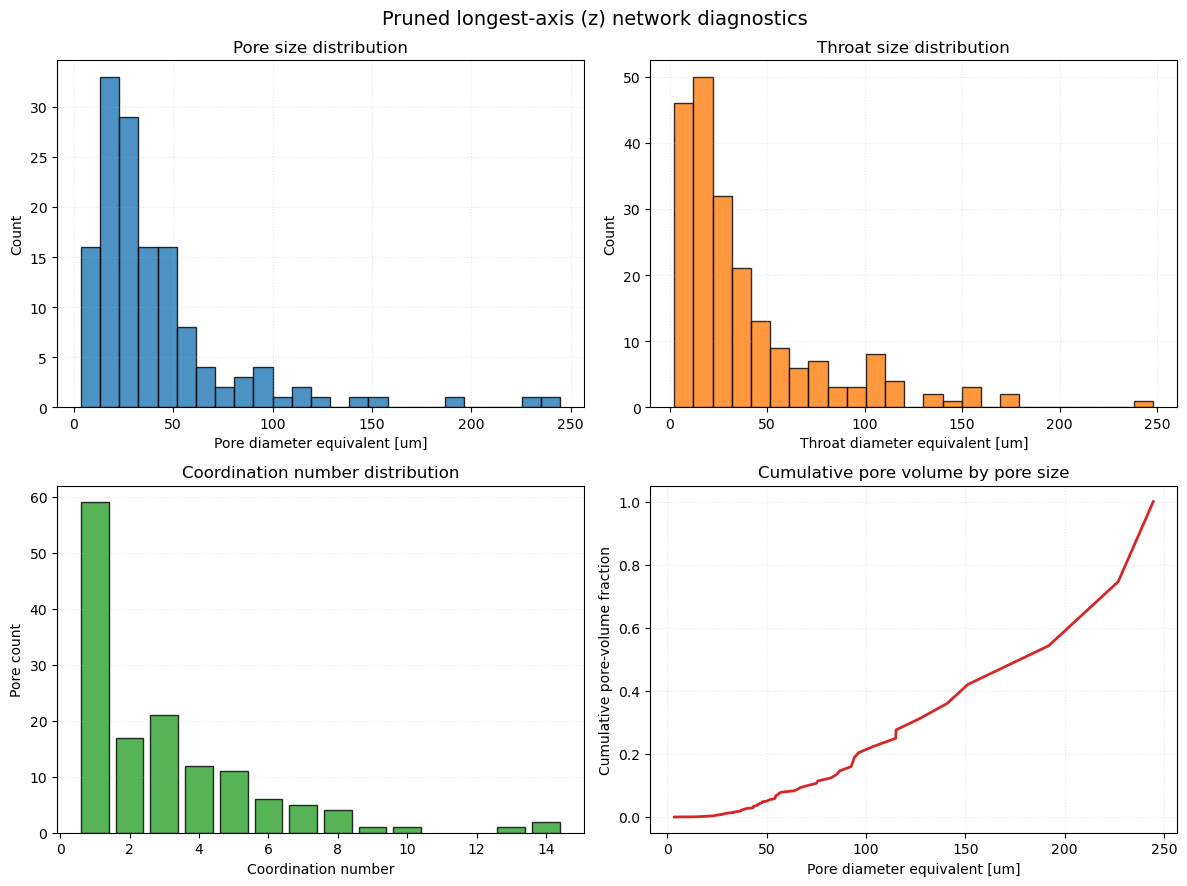

Pore size field: diameter_equivalent
Throat size field: diameter_equivalent
Mean pore size: 40.79 um
Median pore size: 28.76 um
Mean throat size: 38.51 um
Median throat size: 24.93 um
Mean coordination number: 3.01
Max coordination number: 14


In [9]:
pore_size_m, pore_size_field = characteristic_size(net.pore, expected_shape=(net.Np,))
throat_size_m, throat_size_field = characteristic_size(
    net.throat, expected_shape=(net.Nt,)
)
pore_size_name = pore_size_field.replace("_", " ")
throat_size_name = throat_size_field.replace("_", " ")
pore_size_um = 1.0e6 * pore_size_m
throat_size_um = 1.0e6 * throat_size_m

coordination = coordination_numbers(net)
coord_vals, coord_counts = np.unique(coordination, return_counts=True)

pore_volume = np.asarray(net.pore.get("region_volume", net.pore["volume"]), dtype=float)
order = np.argsort(pore_size_um)
cum_pore_volume = np.cumsum(pore_volume[order]) / pore_volume.sum()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].hist(pore_size_um, bins=25, color="tab:blue", edgecolor="black", alpha=0.8)
axes[0, 0].set_xlabel(f"Pore {pore_size_name} [um]")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Pore size distribution")
axes[0, 0].grid(alpha=0.3, linestyle=":")

axes[0, 1].hist(
    throat_size_um, bins=25, color="tab:orange", edgecolor="black", alpha=0.8
)
axes[0, 1].set_xlabel(f"Throat {throat_size_name} [um]")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Throat size distribution")
axes[0, 1].grid(alpha=0.3, linestyle=":")

axes[1, 0].bar(
    coord_vals, coord_counts, width=0.8, color="tab:green", edgecolor="black", alpha=0.8
)
axes[1, 0].set_xlabel("Coordination number")
axes[1, 0].set_ylabel("Pore count")
axes[1, 0].set_title("Coordination number distribution")
axes[1, 0].grid(alpha=0.3, linestyle=":", axis="y")

axes[1, 1].plot(pore_size_um[order], cum_pore_volume, color="tab:red", linewidth=2)
axes[1, 1].set_xlabel(f"Pore {pore_size_name} [um]")
axes[1, 1].set_ylabel("Cumulative pore-volume fraction")
axes[1, 1].set_title("Cumulative pore volume by pore size")
axes[1, 1].grid(alpha=0.3, linestyle=":")

fig.suptitle(f"Pruned longest-axis ({flow_axis}) network diagnostics", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Pore size field: {pore_size_field}")
print(f"Throat size field: {throat_size_field}")
print(f"Mean pore size: {pore_size_um.mean():.2f} um")
print(f"Median pore size: {np.median(pore_size_um):.2f} um")
print(f"Mean throat size: {throat_size_um.mean():.2f} um")
print(f"Median throat size: {np.median(throat_size_um):.2f} um")
print(f"Mean coordination number: {coordination.mean():.2f}")
print(f"Max coordination number: {coordination.max()}")

## Pruning Comparison

Compare the full extracted network (`net_full`) against the longest-axis spanning pruned network (`net`) to quantify what pruning removed and which transport-relevant statistics were preserved.

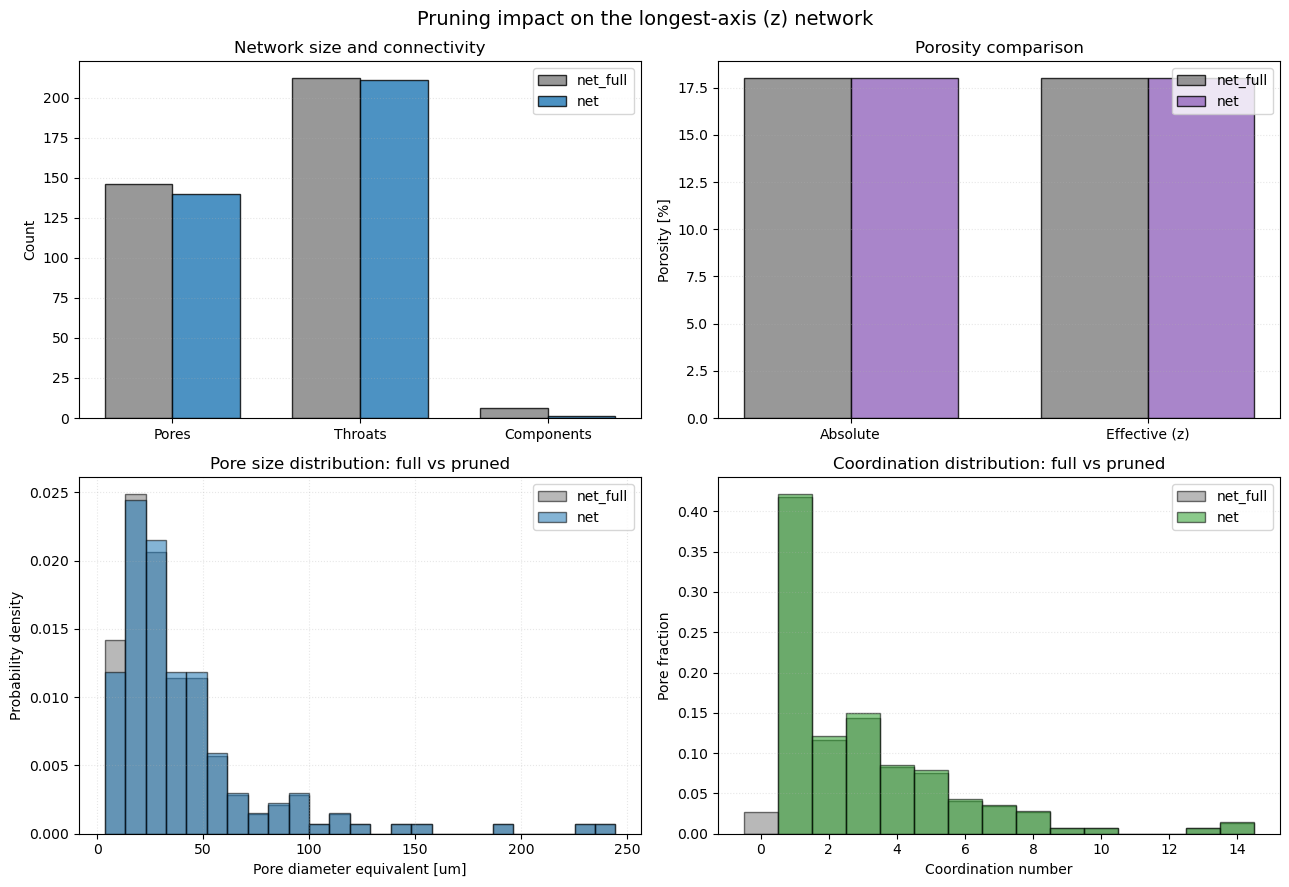

Full network: 146 pores, 212 throats, 6 connected components
Pruned network: 140 pores, 211 throats, 1 connected components
Removed by pruning: 6 pores, 1 throats, 5 components
Retained fractions: pores=95.89%, throats=99.53%, pore volume=99.98%
Absolute porosity: full=17.996%, pruned=17.993%
Effective porosity (z): full=17.993%, pruned=17.993%


In [10]:
full_pore_size_m, full_pore_size_field = characteristic_size(
    net_full.pore, expected_shape=(net_full.Np,)
)
pruned_pore_size_m, pruned_pore_size_field = characteristic_size(
    net.pore, expected_shape=(net.Np,)
)
full_pore_size_um = 1.0e6 * full_pore_size_m
pruned_pore_size_um = 1.0e6 * pruned_pore_size_m
full_coordination = coordination_numbers(net_full)
pruned_coordination = coordination_numbers(net)
full_pore_volume = np.asarray(
    net_full.pore.get("region_volume", net_full.pore["volume"]), dtype=float
)
pruned_pore_volume = np.asarray(
    net.pore.get("region_volume", net.pore["volume"]), dtype=float
)

phi_abs_full = absolute_porosity(net_full)
phi_abs_pruned = absolute_porosity(net)
phi_eff_full = effective_porosity(net_full, axis=flow_axis)
phi_eff_pruned = effective_porosity(net, axis=flow_axis)

n_comp_full, _ = connected_components(net_full)
n_comp_pruned, _ = connected_components(net)

removed_pores = net_full.Np - net.Np
removed_throats = net_full.Nt - net.Nt
removed_components = n_comp_full - n_comp_pruned
retained_pore_fraction = net.Np / net_full.Np if net_full.Np else np.nan
retained_throat_fraction = net.Nt / net_full.Nt if net_full.Nt else np.nan
retained_pore_volume_fraction = (
    pruned_pore_volume.sum() / full_pore_volume.sum()
    if full_pore_volume.sum()
    else np.nan
)
full_coordination_weights = (
    np.full(full_coordination.shape, 1.0 / full_coordination.size)
    if full_coordination.size
    else None
)
pruned_coordination_weights = (
    np.full(pruned_coordination.shape, 1.0 / pruned_coordination.size)
    if pruned_coordination.size
    else None
)

count_names = ["Pores", "Throats", "Components"]
full_counts = np.array([net_full.Np, net_full.Nt, n_comp_full], dtype=float)
pruned_counts = np.array([net.Np, net.Nt, n_comp_pruned], dtype=float)
porosity_names = ["Absolute", f"Effective ({flow_axis})"]
full_porosity_pct = 100.0 * np.array([phi_abs_full, phi_eff_full], dtype=float)
pruned_porosity_pct = 100.0 * np.array([phi_abs_pruned, phi_eff_pruned], dtype=float)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

x = np.arange(len(count_names))
width = 0.36
axes[0, 0].bar(
    x - width / 2,
    full_counts,
    width=width,
    label="net_full",
    color="tab:gray",
    edgecolor="black",
    alpha=0.8,
)
axes[0, 0].bar(
    x + width / 2,
    pruned_counts,
    width=width,
    label="net",
    color="tab:blue",
    edgecolor="black",
    alpha=0.8,
)
axes[0, 0].set_xticks(x, count_names)
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Network size and connectivity")
axes[0, 0].grid(alpha=0.3, linestyle=":", axis="y")
axes[0, 0].legend()

x = np.arange(len(porosity_names))
axes[0, 1].bar(
    x - width / 2,
    full_porosity_pct,
    width=width,
    label="net_full",
    color="tab:gray",
    edgecolor="black",
    alpha=0.8,
)
axes[0, 1].bar(
    x + width / 2,
    pruned_porosity_pct,
    width=width,
    label="net",
    color="tab:purple",
    edgecolor="black",
    alpha=0.8,
)
axes[0, 1].set_xticks(x, porosity_names)
axes[0, 1].set_ylabel("Porosity [%]")
axes[0, 1].set_title("Porosity comparison")
axes[0, 1].grid(alpha=0.3, linestyle=":", axis="y")
axes[0, 1].legend()

pore_bins = np.histogram_bin_edges(
    np.concatenate([full_pore_size_um, pruned_pore_size_um]), bins=25
)
axes[1, 0].hist(
    full_pore_size_um,
    bins=pore_bins,
    density=True,
    alpha=0.55,
    label="net_full",
    color="tab:gray",
    edgecolor="black",
)
axes[1, 0].hist(
    pruned_pore_size_um,
    bins=pore_bins,
    density=True,
    alpha=0.55,
    label="net",
    color="tab:blue",
    edgecolor="black",
)
axes[1, 0].set_xlabel(f"Pore {pruned_pore_size_field.replace('_', ' ')} [um]")
axes[1, 0].set_ylabel("Probability density")
axes[1, 0].set_title("Pore size distribution: full vs pruned")
axes[1, 0].grid(alpha=0.3, linestyle=":")
axes[1, 0].legend()

max_coordination = max(
    int(np.max(full_coordination)) if full_coordination.size else 0,
    int(np.max(pruned_coordination)) if pruned_coordination.size else 0,
    1,
)
coord_bins = np.arange(-0.5, max_coordination + 1.5, 1.0)
axes[1, 1].hist(
    full_coordination,
    bins=coord_bins,
    weights=full_coordination_weights,
    alpha=0.55,
    label="net_full",
    color="tab:gray",
    edgecolor="black",
)
axes[1, 1].hist(
    pruned_coordination,
    bins=coord_bins,
    weights=pruned_coordination_weights,
    alpha=0.55,
    label="net",
    color="tab:green",
    edgecolor="black",
)
axes[1, 1].set_xlabel("Coordination number")
axes[1, 1].set_ylabel("Pore fraction")
axes[1, 1].set_title("Coordination distribution: full vs pruned")
axes[1, 1].grid(alpha=0.3, linestyle=":", axis="y")
axes[1, 1].legend()

fig.suptitle(f"Pruning impact on the longest-axis ({flow_axis}) network", fontsize=14)
plt.tight_layout()
plt.show()

print(
    f"Full network: {net_full.Np} pores, {net_full.Nt} throats, {n_comp_full} connected components"
)
print(
    f"Pruned network: {net.Np} pores, {net.Nt} throats, {n_comp_pruned} connected components"
)
print(
    f"Removed by pruning: {removed_pores} pores, {removed_throats} throats, {removed_components} components"
)
print(
    f"Retained fractions: pores={100.0 * retained_pore_fraction:.2f}%, throats={100.0 * retained_throat_fraction:.2f}%, pore volume={100.0 * retained_pore_volume_fraction:.2f}%"
)
print(
    f"Absolute porosity: full={100.0 * phi_abs_full:.3f}%, pruned={100.0 * phi_abs_pruned:.3f}%"
)
print(
    f"Effective porosity ({flow_axis}): full={100.0 * phi_eff_full:.3f}%, pruned={100.0 * phi_eff_pruned:.3f}%"
)

## Interactive network visualization

Visualize the extracted pore network with pores colored by pressure using Plotly for full 3D interactivity.

In [11]:
try:
    fig = plot_network_plotly(
        net,
        point_scalars=res.pore_pressure,
        max_throats=1000,
        title=f"Extracted longest-axis ({flow_axis}) pore network - interactive pressure field",
        layout_kwargs={"width": 900, "height": 700},
    )
    fig.show()
    print(f"Network: {net.Np} pores, {net.Nt} throats")
    p_plot = res.pore_pressure[np.isfinite(res.pore_pressure)]
    print(f"Pressure range: {p_plot.min():.2e} to {p_plot.max():.2e} Pa")
except ImportError as exc:
    print(exc)

Network: 140 pores, 211 throats
Pressure range: 1.00e+05 to 2.00e+05 Pa
